In [1]:
# Standard Library
import os
import random
from pathlib import Path

# Numerical Computing & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image

# TorchVision
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
# Data Loading Utilities
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

from tqdm import tqdm

## Configuration

In [2]:
DATASET_PATH = Path("data/raw/PlantVillage")

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
DEVICE

device(type='cpu')

In [3]:
DATASET_PATH.iterdir()

<generator object Path.iterdir at 0x000001E55C175540>

## Image Preprocessing

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Load Dataset

In [5]:
full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transforms
)

class_names = full_dataset.classes

print(f"Total Classes : {len(class_names)}")
print(class_names)

Total Classes : 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")

Training Images   : 16510
Validation Images : 4128


In [7]:
# ================================
# Create DataLoaders
# ================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")

Training Batches   : 516
Validation Batches : 129


In [8]:
# ================================
# Check One Batch
# ================================

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

d:\Rajat thakur\Projects\KrishiVaidya\.venv\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])


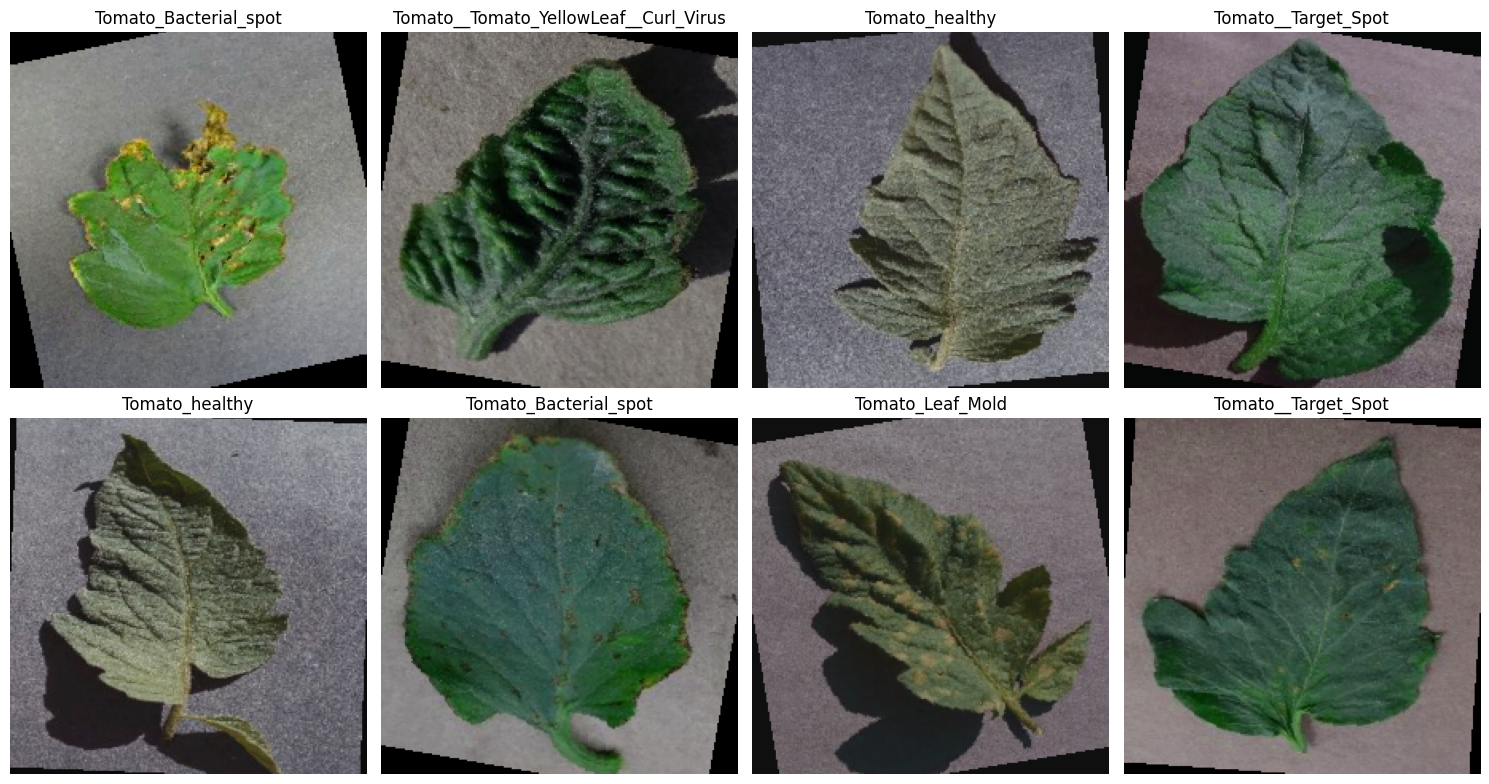

In [9]:
# ================================
# Display Sample Images
# ================================

def imshow(img):
    img = img.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")


plt.figure(figsize=(15, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(class_names[labels[i]])

plt.tight_layout()
plt.show()

In [10]:
# ================================
# Load EfficientNet-B0
# ================================

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

In [11]:
# Replace final layer

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    len(class_names)
)

In [12]:
model = model.to(DEVICE)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [13]:
# ================================
# Loss & Optimizer
# ================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

## Model Training

Setup

In [14]:
best_val_acc = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [ ]:
for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-"*50)

    # TRAINING
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


Epoch [1/10]
--------------------------------------------------


100%|██████████| 516/516 [40:46<00:00,  4.74s/it]



Epoch [2/10]
--------------------------------------------------


 20%|█▉        | 102/516 [09:01<36:36,  5.31s/it]


KeyboardInterrupt: 

Validation

In [ ]:
model.eval()

running_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

val_loss = running_loss / len(val_loader)
val_acc = 100 * correct / total

val_losses.append(val_loss)
val_accuracies.append(val_acc)

In [ ]:
print(f"Train Loss : {train_loss:.4f}")
print(f"Train Acc  : {train_acc:.2f}%")

print(f"Val Loss   : {val_loss:.4f}")
print(f"Val Acc    : {val_acc:.2f}%")

In [ ]:
if val_acc > best_val_acc:

    best_val_acc = val_acc

    torch.save(model.state_dict(), "models/best_model.pth")

    print("✅ Best model saved!")

In [ ]:
print("\nTraining Completed!")

print(f"\nBest Validation Accuracy : {best_val_acc:.2f}%")

## UI design